<a href="https://colab.research.google.com/github/clarachence/am-t4-a12026/blob/main/MultiNeuralCensus06015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Randeom Forest | Digest Pickle [Fase 1 - census]

## Importar Dados

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Biblioteca de dados

In [43]:
!pip -q install plotly
!pip -q install yellowbrick

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.palettes
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [45]:
import pickle

In [46]:
with open('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_census_treinamento = le.fit_transform(Y_census_treinamento)
Y_census_teste = le.transform(Y_census_teste)

In [48]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [49]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [52]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([0, 0, 0, ..., 0, 0, 1])

## Criando base Previsora

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [55]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [56]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

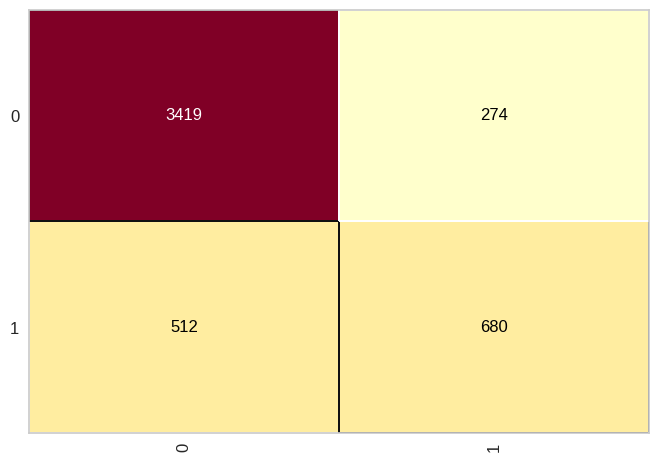

In [57]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [58]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      3693
           1       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 1 census base]

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(random_state=1)

In [61]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [62]:
regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([0, 0, 0, ..., 0, 0, 1])

In [63]:

accuracy_score(Y_census_teste, regression_previsores)

0.8497441146366428

0.8497441146366428

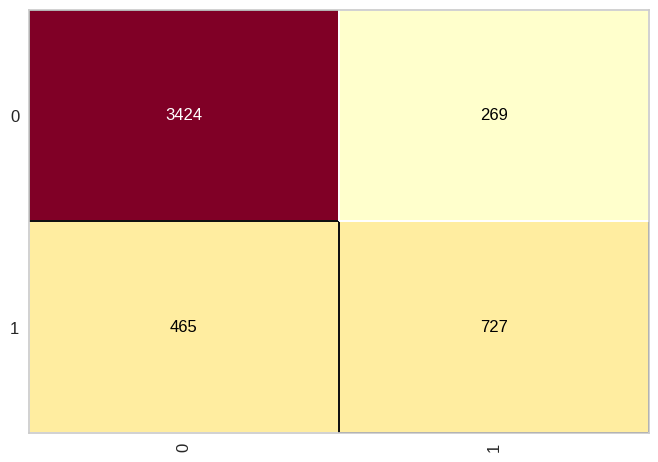

In [64]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(regressao_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)


In [65]:
print(classification_report(Y_census_teste, regression_previsores))


              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3693
           1       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline SVM | Digest [Fase 1 census Base]

In [66]:
from sklearn.svm import SVC

In [67]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_treinamento, Y_census_treinamento)

SVC(C=2.0, random_state=1)

In [68]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [69]:
svm_previsoes = svm_census.predict(X_census_teste)
svm_previsoes

array([0, 0, 0, ..., 0, 0, 1])

In [70]:
accuracy_score(Y_census_teste, svm_previsoes)

0.8485158648925282

0.8485158648925282

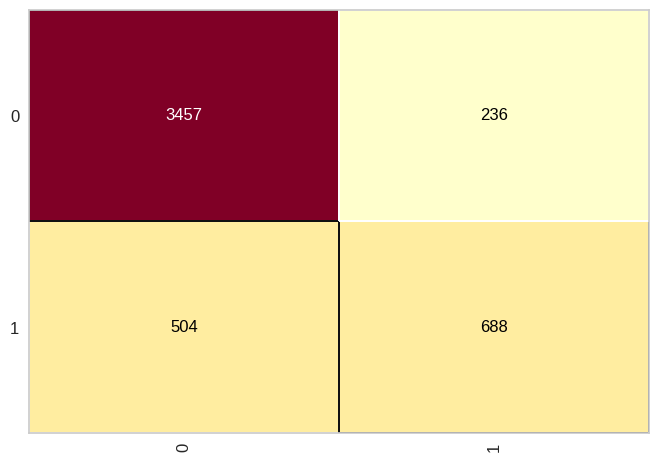

In [71]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_treinamento, Y_census_treinamento)
svm_cm.score(X_census_teste, Y_census_teste)

In [72]:
print(classification_report(Y_census_teste, svm_previsoes))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3693
           1       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 1 census Base]

In [73]:
from sklearn.neural_network import MLPClassifier

In [74]:
redeneural_census = MLPClassifier(verbose = True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_census.fit(X_census_treinamento, Y_census_treinamento)

Iteration 1, loss = 0.41586542
Iteration 2, loss = 0.32783287
Iteration 3, loss = 0.31775021
Iteration 4, loss = 0.31044577
Iteration 5, loss = 0.30549732
Iteration 6, loss = 0.30105860
Iteration 7, loss = 0.29858918
Iteration 8, loss = 0.29567414
Iteration 9, loss = 0.29334320
Iteration 10, loss = 0.29162483
Iteration 11, loss = 0.28950061
Iteration 12, loss = 0.28747852
Iteration 13, loss = 0.28576796
Iteration 14, loss = 0.28427596
Iteration 15, loss = 0.28203918
Iteration 16, loss = 0.28112413
Iteration 17, loss = 0.28010676
Iteration 18, loss = 0.27827714
Iteration 19, loss = 0.27777455
Iteration 20, loss = 0.27613820
Iteration 21, loss = 0.27563936
Iteration 22, loss = 0.27430766
Iteration 23, loss = 0.27312841
Iteration 24, loss = 0.27217619
Iteration 25, loss = 0.27116630
Iteration 26, loss = 0.27030997
Iteration 27, loss = 0.26947191
Iteration 28, loss = 0.26797906
Iteration 29, loss = 0.26699099
Iteration 30, loss = 0.26559120
Iteration 31, loss = 0.26584279
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [75]:
redeneural_census.out_activation_

'logistic'

In [76]:
previsoes_redeneural = redeneural_census.predict(X_census_teste)
previsoes_redeneural

array([0, 0, 0, ..., 0, 0, 1])

In [77]:
accuracy_score(Y_census_teste, previsoes_redeneural)

0.8296827021494371

0.8296827021494371

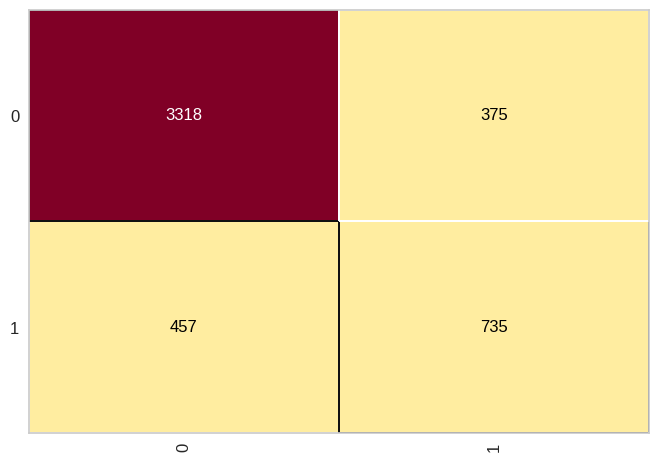

In [78]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_treinamento, Y_census_treinamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [79]:
print(classification_report(Y_census_teste, previsoes_redeneural))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      3693
           1       0.66      0.62      0.64      1192

    accuracy                           0.83      4885
   macro avg       0.77      0.76      0.76      4885
weighted avg       0.83      0.83      0.83      4885



# Pipeline de Preparação dos Dados | census_Base [Fase 1]

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [81]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1, 2]}

In [82]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento)
melhor_parametros_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametros_census)

{'n_neighbors': 20, 'p': 1}
